# Model Architecture

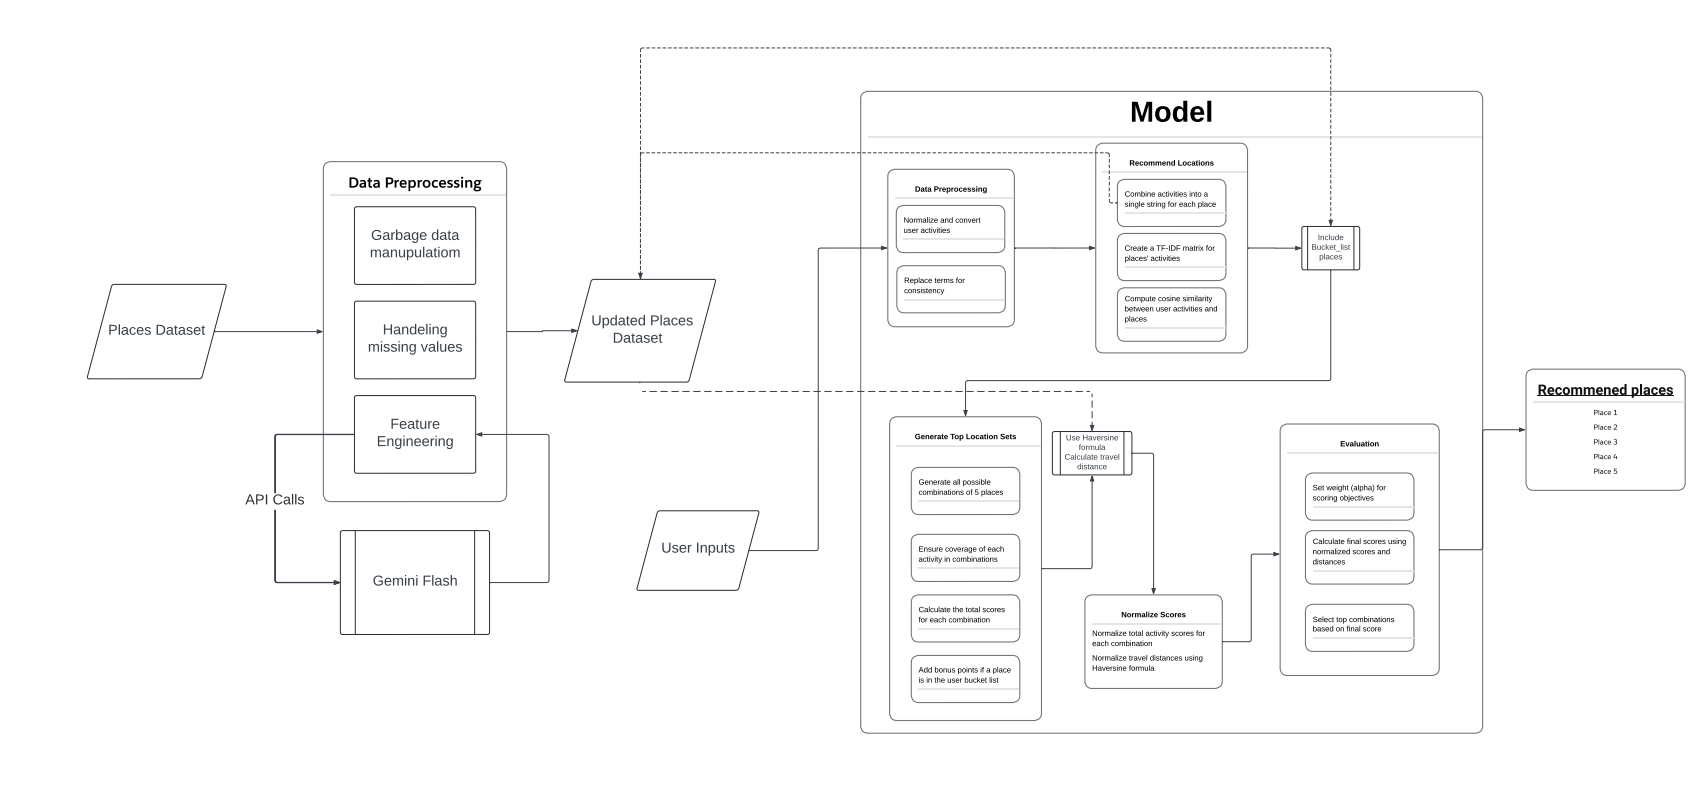

# Import libraries and data

In [ ]:
import numpy as np 
import pandas as pd 
import re
from fuzzywuzzy import fuzz # for string matching
from fuzzywuzzy import process # for string matching
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm  # Import tqdm for progress logging
import logging
from textblob import TextBlob
import google.generativeai as genai
from collections import defaultdict
import time

In [ ]:
places_df = pd.read_csv('/kaggle/input/gemini-long-context-dataset/Recommendation  model data/Places Dataset.xlsx - places_final_dataset.csv')
users_df = pd.read_csv('/kaggle/input/gemini-long-context-dataset/Recommendation  model data/Visitors Preference Dataset.xlsx - user_data_version_3_10K_Users.csv')

# Exploratory data analysis

In [ ]:
places_df.head()

In [ ]:
users_df.head()

In [ ]:
#Function to analyze data
def customDescription(df: pd.DataFrame, numeric_only: bool = False):
    if numeric_only:
        df = df.select_dtypes(include=np.number)
    
    desc = pd.DataFrame(index=df.columns.to_list())
    desc['type'] = df.dtypes
    desc['count'] = df.count()
    desc['nunique'] = df.nunique()
    desc['null'] = df.isnull().sum()
    
    # Handle numeric columns separately
    if not df.select_dtypes(include=np.number).empty:
        numeric_desc = df.describe().T.drop(columns=['count','std','25%','50%','75%'], axis=1)
        for col in df.select_dtypes(include=np.number).columns:
            desc.loc[col, 'mean'] = numeric_desc.loc[col, 'mean']
            desc.loc[col, 'min'] = numeric_desc.loc[col, 'min']
            desc.loc[col, 'max'] = numeric_desc.loc[col, 'max']
    
    # Handle non-numeric columns separately
    if not df.select_dtypes(exclude=np.number).empty:
        non_numeric_desc = df.select_dtypes(exclude=np.number).describe().T
        desc = pd.concat([desc, non_numeric_desc.drop(columns=['count', 'unique', 'top', 'freq'], axis=1, errors='ignore')], axis=1)
    
    return desc

In [ ]:
customDescription(users_df)

In [ ]:
customDescription(places_df)

In [ ]:
print("Shape of places table:",places_df.shape)
print("Shape of users table:",users_df.shape)

##### Notes:

* places dataset includes 1 null value in lat & lng and 56 null values in rating & user_ratings_total.
* Seems like there are some duplicated data also.
* Need to check whether both prefferd activities and bucket list are taken from a dropdown list or simply typed by each user.
* If they are selected from a drop down, totally fine.
* Otherwise we need to identify and merge identical activities across different forms to streamline data.

In [ ]:
unique_activities = users_df['Preferred Activities'].unique()
activities = set()

for activity in unique_activities:
    activity_set = activity.strip("[]'").replace("'", "").split(", ")
    activities.update(activity_set)

sorted_activities = sorted(activities)

print(f"Number of unique activities: {len(sorted_activities)}")
print("Unique activities in alphabetical order:")
for activity in sorted_activities:
    print(activity)

##### Notes:
* This analysis shows that the activities are from a dropdown selection or a selection of activities that the user can choose from. All good!


# Data Preprocessing

#### Let's remove non-English characters in places dataset

In [ ]:
import re

def clean_text(text):
    # Remove all characters except alphabets, numbers, and punctuation
    #cleaned = re.sub(r'[^\w\s.,!?;:()-]', '', str(text))
    cleaned = re.sub(r'[^A-Za-z\s.,]', '', str(text))
    # Normalize spaces
    cleaned = re.sub(r'\s+', ' ', cleaned)
    return cleaned.strip()

# Apply the cleaning function to the 'name', 'latest_reviews' and 'formatted_address' columns in the places dataframe
places_df['name'] = places_df['name'].apply(clean_text)
places_df['latest_reviews'] = places_df['latest_reviews'].apply(clean_text)
places_df['formatted_address'] = places_df['formatted_address'].apply(clean_text)

#### Let's manipulate the duplicates in places dataset

In [ ]:
# Find duplicated names
duplicated_names = places_df[places_df.duplicated(subset='name', keep=False)]
duplicated_names_sorted = duplicated_names.sort_values('name')

# Display the results
print(f"Number of entries with duplicated names: {len(duplicated_names)}")

# Group duplicates and aggregate
def aggregate_duplicates(group):
    first_record = group.iloc[0]
    second_record = group.iloc[1] if len(group) > 1 else None
    
    # Take lat, lng, formatted_address from the first record, if present, otherwise from the second
    lat = first_record['lat'] if pd.notna(first_record['lat']) else (second_record['lat'] if second_record is not None else None)
    lng = first_record['lng'] if pd.notna(first_record['lng']) else (second_record['lng'] if second_record is not None else None)
    formatted_address = first_record['formatted_address'] if pd.notna(first_record['formatted_address']) else (second_record['formatted_address'] if second_record is not None else None)
    
    # Calculate weighted average rating
    total_ratings = group['user_ratings_total'].sum()
    if total_ratings > 0:
        weighted_rating = (group['rating'] * group['user_ratings_total']).sum() / total_ratings
    else:
        weighted_rating = group['rating'].mean()
    
    # Combine latest_reviews
    combined_reviews = ' '.join(group['latest_reviews'].dropna())
    
    return pd.Series({
        'lat': lat,
        'lng': lng,
        'formatted_address': formatted_address,
        'rating': weighted_rating,
        'user_ratings_total': total_ratings,
        'latest_reviews': combined_reviews
    })

# Apply the aggregation
places_deduplicated = places_df.groupby('name').apply(aggregate_duplicates).reset_index()

# Print the results
print(f"Number of entries before deduplication: {len(places_df)}")
print(f"Number of entries after deduplication: {len(places_deduplicated)}")

# Update the original places dataframe
places_df = places_deduplicated

In [ ]:
# Removing 'Anuradhapura' and 'Colombo' because we have 'Anuradhapura New Town' and 'Colombo City Tour'
places_df = places_df[~places_df['name'].isin(['Anuradhapura', 'Colombo'])]
places_df = places_df.reset_index(drop=True)

#### Let's fix the `formatted_address` section in places dataset

In [ ]:
# Remove 'Sri Lanka' from the formatted_address column
places_df['formatted_address'] = places_df['formatted_address'].str.replace(', Sri Lanka', '', regex=False)

In [ ]:
places_df[places_df['formatted_address'] == ""]

In [ ]:
places_df[places_df['formatted_address'] == "Sri"]

In [ ]:
places_df[places_df['formatted_address'] == "Sri Lanka"]

In [ ]:
places_df.loc[places_df['name'] == 'Coral Sanctuary Boat Ticket Issue Center', 'formatted_address'] = 'Hikkaduwa'
places_df.loc[places_df['name'] == 'Fort Entrance Old Gate', 'formatted_address'] = 'Galle'
places_df.loc[places_df['name'] == 'Kudawa Beach Kalpitiya', 'formatted_address'] = 'Kalpitiya'
places_df.loc[places_df['name'] == 'Mayan Water Park', 'formatted_address'] = 'Negombo'
places_df.loc[places_df['name'] == 'Kanneliya National Rain Forest Reserve', 'formatted_address'] = 'Kanneliya'
places_df.loc[places_df['name'] == 'Alankuda Casuarina Beach', 'formatted_address'] = 'Kalpitiya'
places_df.loc[places_df['name'] == 'Bambarakiri Ella', 'formatted_address'] = 'Kandy'
places_df.loc[places_df['name'] == 'Bathalagoda Tank', 'formatted_address'] = 'Kurunegala'
places_df.loc[places_df['name'] == 'Dutch Bay Beach', 'formatted_address'] = 'Trincomalee'
places_df.loc[places_df['name'] == 'Horton Plains National Park', 'formatted_address'] = 'Nuwara Eliya'
places_df.loc[places_df['name'] == 'Kattukkarai Kulam', 'formatted_address'] = 'Vavuniya'
places_df.loc[places_df['name'] == 'Kokkilai Beach', 'formatted_address'] = 'Kokkilai'
places_df.loc[places_df['name'] == 'Korathota Royal Temple', 'formatted_address'] = 'Korathota'
places_df.loc[places_df['name'] == 'Leisure World', 'formatted_address'] = 'Hanwella'
places_df.loc[places_df['name'] == 'Madunagala Hot Water Spring', 'formatted_address'] = 'Hambantota'
places_df.loc[places_df['name'] == 'Manelwatta Temple', 'formatted_address'] = 'Gampaha'
places_df.loc[places_df['name'] == 'Midigama Right', 'formatted_address'] = 'Midigama'
places_df.loc[places_df['name'] == 'Minneriya National Park', 'formatted_address'] = 'Habarana'
places_df.loc[places_df['name'] == 'Rajanawa Waterfall', 'formatted_address'] = 'Ratnapura'
places_df.loc[places_df['name'] == 'Sinharaja Rain Forest', 'formatted_address'] = 'Sinharaja Forest Reserve'
places_df.loc[places_df['name'] == 'Thalawila Beach', 'formatted_address'] = 'Kalpitiya'
places_df.loc[places_df['name'] == 'Udawalawe National Park', 'formatted_address'] = 'Udawalawe'
places_df.loc[places_df['name'] == 'Vankalai Bird Sanctuary', 'formatted_address'] = 'Mannar'
places_df.loc[places_df['name'] == 'Wilpattu National Park', 'formatted_address'] = 'Puttalam'	
places_df.loc[places_df['name'] == 'Yala National Park', 'formatted_address'] = 'Hambantota'
places_df.loc[places_df['name'] == 'Aanda Ella Fall', 'formatted_address'] = 'Ratnapura'	

#### Handeling missing values

In [ ]:
# Check for null values in lat or lng columns
null_lat_lng = places_df[places_df['lat'].isnull() | places_df['lng'].isnull()]
null_lat_lng

In [ ]:
# Manually add lat and lng
places_df.loc[places_df['name'] == 'Leisure World', 'lat'] = 6.9167
places_df.loc[places_df['name'] == 'Leisure World', 'lng'] = 80.0667

In [ ]:
# Check for null values in the rating column
null_ratings = places_df[places_df['rating'].isnull()]
num_null_ratings = null_ratings.shape[0]
print(f"\nNumber of places with null ratings: {num_null_ratings}")

##### Notes:
* As these places are more like main cities there isn't ratings foe these places in google maps. We need to find a other way to fill them.

In [ ]:
sorted_bucket_places

In [ ]:
places_df['name']

#### Identifying places on both datasets

In [ ]:
# Convert places['name'] to a set for efficient comparison
places_set = set(places_df['name'].str.lower().str.strip())

# Convert sorted_bucket_places to a set of lowercase strings for comparison
bucket_places_set = set(place.lower().strip() for place in sorted_bucket_places)

# Find common places
common_places = places_set.intersection(bucket_places_set)

# Sort the common places for easier reading
common_places_sorted = sorted(common_places)

# Print the results
print(f"Number of places in both datasets: {len(common_places)}")
print("\nPlaces that appear in both 'places' dataset and bucket list:")
for place in common_places_sorted:
    print(f"- {place}")

# Optional: Find places only in 'places' dataset
places_only = places_set - bucket_places_set
print(f"\nNumber of places only in 'places' dataset: {len(places_only)}")

# Optional: Find places only in bucket list
bucket_only = bucket_places_set - places_set
print(f"Number of places only in bucket list: {len(bucket_only)}")

In [ ]:
sorted_activities = [activity.replace('safaris', 'wild life safaris').replace('hot air ballooning', 'air ballooning') for activity in sorted_activities]
sorted_activities

# Gemini Long Context in Action

### Let's extract relevant activities and their corresponding satisfaction scores for each location using gemini long context window 

In [ ]:
places_df['extracted_activities'] = None
places_df['activity_scores'] = None

In [ ]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
key1 = user_secrets.get_secret("gemini api key 1  ")
key2 = user_secrets.get_secret("gemini api key 2")


# Configure the Google Generative AI
def configure_genai(key):
    genai.configure(api_key=key)
    generation_config = {
        "temperature": 0.7,
        "top_p": 0.9,
        "max_output_tokens": 1000,
        "response_mime_type": "text/plain",
    }
    return genai.GenerativeModel(
        model_name="gemini-1.5-flash",
        generation_config=generation_config,
    )

def extract_activities_and_scores(review, candidate_activities, model):
    prompt = f"Extract all the activities and their satisfaction scores from the following reviews: {review}. The activities should be from the following list: {candidate_activities}. Give the response in this format: Activity name(in lowercase as in the given list) - satisfaction score(0-5). If there are many activities, add them line by line in the same format. remove markdown syntaxs and don't add details that are not required."
    chat_session = model.start_chat(history=[])
    response = chat_session.send_message(prompt)
    return response.text

def parse_and_average_extracted_data(extracted_data):
    activity_scores = defaultdict(list)
    lines = extracted_data.strip().split('\n')
    
    for line in lines:
        if ' - ' in line:
            activity, score = line.split(' - ')
            activity = activity.strip()
            score = float(score.strip())
            activity_scores[activity].append(score)

    averaged_activities = []
    averaged_scores = []
    
    for activity, scores in activity_scores.items():
        averaged_activities.append(activity)
        averaged_scores.append(sum(scores) / len(scores))

    return averaged_activities, averaged_scores

# Process rows in batches of 10
batch_size = 10
total_rows = len(places_df)

for start_idx in range(0, total_rows, batch_size):
    end_idx = min(start_idx + batch_size, total_rows)
    
    # Alternate between keys
    current_key = key1 if (start_idx // batch_size) % 2 == 0 else key2
    model = configure_genai(current_key)
    
    for i in range(start_idx, end_idx):
        review = places_df.iloc[i]['latest_reviews']
        extracted_data = extract_activities_and_scores(review, sorted_activities, model)
        
        activities, scores = parse_and_average_extracted_data(extracted_data)
        
        places_df.at[i, 'extracted_activities'] = activities
        places_df.at[i, 'activity_scores'] = scores
        
        del activities, scores, review, extracted_data
    
    print(f"Processed rows {start_idx} to {end_idx-1}")
    
    # Add a delay between batches to avoid hitting rate limits
    if end_idx < total_rows:
        time.sleep(30)  # Wait for 60 seconds between batches

##### Notes:
* I processed the places_df in batches of 10 rows to extract activities and their scores from the reviews.
* The Gemini long context really shines here because these reviews really long in context.
* I alternated between two gemini API keys (key1 and key2) to avoid hitting rate limits.
* The extracted activities and their scores were stored in the 'extracted_activities' and 'activity_scores' columns of places_df.df.
cost.

In [ ]:
def weighted_rating(row, m=50, C=places_df['rating'].mean()):
    v = row['user_ratings_total']
    R = row['rating']
    return (v / (v + m) * R) + (m / (v + m) * C)

places_df['rating'] = places_df.apply(weighted_rating, axis=1)
places_df.drop(columns=['user_ratings_total'], inplace=True)

places_df.head(10)

##### Notes:

* We implemented a weighted rating system to provide a more balanced and reliable rating for each place.
* This approach combines the average rating with the number of ratings, giving more weight to places with a higher number of reviews. The formula used is known as the Bayesian average, which helps to mitigate the impact of places with very few ratings that might skew the results.

In [ ]:
# Remove [, ], ', " signs in Preferred Activities and Bucket list destinations Sri Lanka
users_df['Preferred Activities'] = users_df['Preferred Activities'].str.replace(r"[\[\]'\"']", "", regex=True)
users_df['Bucket list destinations Sri Lanka'] = users_df['Bucket list destinations Sri Lanka'].str.replace(r"[\[\]'\"']", "", regex=True)

##### Eliminating unnecessary features for future modeling

In [ ]:
places_df.drop(columns=['latest_reviews'], inplace=True)
users_df.drop(columns=['Name'], inplace=True)
users_df.drop(columns=['User ID'], inplace=True)
users_df.drop(columns=['Email'], inplace=True)

##### Saving final preprocessed datasets

In [ ]:
users_df.to_csv('users_preprocessed.csv', index=False)

In [ ]:
places_df.to_csv('places_preprocessed.csv', index=False)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd
from itertools import combinations, permutations
import ast
import dill

In [ ]:
places_df = pd.read_csv('/kaggle/input/gemini-long-context-dataset/Recommendation  model data/places_preprocessed.csv')
users_df = pd.read_csv('/kaggle/input/gemini-long-context-dataset/Recommendation  model data/users_preprocessed.csv')

In [ ]:
def recommend_locations(user_activities, places, user_bucket_list, top_n_per_activity=5):
    # Combine all activities into a single string for each place
    places['combined_activities'] = places['extracted_activities'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))
    
    # Create a TF-IDF Vectorizer with lowered max_df and increased min_df
    vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
    
    try:
        # Fit and transform the combined activities
        tfidf_matrix = vectorizer.fit_transform(places['combined_activities'])
        
        # Transform the user's preferred activities
        user_activities_str = ' '.join(user_activities)
        user_tfidf = vectorizer.transform([user_activities_str])
        
        # Calculate cosine similarities between user activities and place activities
        cosine_similarities = cosine_similarity(user_tfidf, tfidf_matrix).flatten()
        
        # Get the indices of the top_n_per_activity places with the highest similarity scores for each activity
        top_indices = set()
        for activity in user_activities:
            activity_tfidf = vectorizer.transform([activity])
            activity_similarities = cosine_similarity(activity_tfidf, tfidf_matrix).flatten()
            activity_top_indices = activity_similarities.argsort()[-top_n_per_activity:][::-1]
            top_indices.update(activity_top_indices)
        
        # Convert the set to a sorted list based on overall cosine similarity and keep only the top 15 unique places
        top_indices = sorted(top_indices, key=lambda idx: cosine_similarities[idx], reverse=True)[:15]
        
        # Get the recommended locations
        recommended_locations = places.iloc[top_indices].copy()
    except ValueError:
        # If vectorization fails, return all places without duplicates
        print("Vectorization failed. Returning all unique places.")
        recommended_locations = places.drop_duplicates(subset=['name'])
    
    # Add unique places from user's bucket list
    for bucket_item in user_bucket_list:
        matched_places = places[
            (places['name'].str.lower() == bucket_item.lower()) | 
            (places['formatted_address'].str.lower() == bucket_item.lower())
        ]
        # Exclude already recommended places
        matched_places = matched_places[~matched_places.index.isin(recommended_locations.index)]
        if not matched_places.empty:
            recommended_locations = pd.concat([recommended_locations, matched_places], ignore_index=True)
            # Ensure no duplicates after adding bucket list places
            recommended_locations = recommended_locations.drop_duplicates(subset=['name'], keep='first')
            # Optionally limit the total number of recommendations
            if len(recommended_locations) >= 15:
                recommended_locations = recommended_locations.head(15)
                break
    
    return recommended_locations

user_activities = users_df.iloc[1]['Preferred Activities'].strip("[]").replace("'", "").split(", ")
user_activities = [
    activity.lower().strip()
    .replace('safaris', 'wild life safaris')
    .replace('hot air ballooning', 'air ballooning') 
    for activity in user_activities
]
user_bucket_list = users_df.iloc[1]['Bucket list destinations Sri Lanka'].strip("[]").replace("'", "").split(", ")
recommended_locations = recommend_locations(user_activities, places_df, user_bucket_list)
print(recommended_locations[['name']])

In [ ]:
def get_places_for_each_activity(user_activities, recommended_locations):
    activity_places = {activity: [] for activity in user_activities}
    
    for activity in user_activities:
        for index, row in recommended_locations.iterrows():
            extracted_activities = row['extracted_activities']
            activity_scores = row['activity_scores']
            
            # Convert string representations to lists if necessary
            if isinstance(extracted_activities, str):
                extracted_activities = ast.literal_eval(extracted_activities)
            if isinstance(activity_scores, str):
                activity_scores = ast.literal_eval(activity_scores)
            
            if activity in extracted_activities:
                activity_index = extracted_activities.index(activity)
                activity_score = activity_scores[activity_index]
                activity_places[activity].append((row['name'], activity_score))
    
    return activity_places

activity_places = get_places_for_each_activity(user_activities, recommended_locations)
for activity, places in activity_places.items():
    print(f"Activity: {activity}")
    for place, score in places:
        print(f"Place: {place}, Score: {score}")
    print()

In [ ]:
# Add bucket list destinations to the score calculation
def get_top_location_sets_with_bucket_list(activity_places, user_bucket_list, top_n=10):
    unique_places = set()
    for places in activity_places.values():
        for place, score in places:
            unique_places.add(place)
    
    # Generate all possible combinations of 5 locations
    all_combinations = list(combinations(unique_places, 5))
    
    # Filter combinations to ensure each activity is covered
    valid_combinations = []
    for combo in all_combinations:
        activity_counts = []
        for activity, places in activity_places.items():
            count = sum(1 for place, score in places if place in combo)
            activity_counts.append(count)
        
        # Check if the combination is valid
        if 0 not in activity_counts and activity_counts.count(1) < 2:
            valid_combinations.append(combo)
    
    if not valid_combinations:
        print("No valid combinations found. Consider adjusting the combination size or activity constraints.")
        return []
    
    # Calculate the sum of activity scores for each valid combination
    combo_scores = []
    for combo in valid_combinations:
        score_sum = 0
        for activity, places in activity_places.items():
            for place, score in places:
                if place in combo:
                    score_sum += score
        # Add 1 for each location if that location or its formatted_address is in the bucket list
        for place in combo:
            if place in user_bucket_list or any(place.lower() in address.lower() for address in user_bucket_list):
                score_sum += 1
        combo_scores.append((combo, score_sum))
    
    # Sort combinations by the highest sum of activity scores
    combo_scores.sort(key=lambda x: x[1], reverse=True)
    
    # Get the top_n combinations
    top_combinations = combo_scores[:top_n]
    
    # Add the rating to the score_sum for the top_n combinations
    final_combinations = []
    for combo, score_sum in top_combinations:
        rating_sum = 0
        rating_count = 0
        for place in combo:
            place_rating = places_df[places_df['name'] == place]['rating'].values
            if len(place_rating) > 0 and not pd.isna(place_rating[0]):
                rating_sum += place_rating[0]
                rating_count += 1
        if rating_count > 0:
            avg_rating = rating_sum / rating_count
            score_sum += avg_rating
        final_combinations.append((combo, score_sum))
    
    # Sort the final combinations by the updated score_sum
    final_combinations.sort(key=lambda x: x[1], reverse=True)
    
    return final_combinations[:top_n]

bucket_list = places_df[places_df['name'].isin(user_bucket_list) | places_df['formatted_address'].isin(user_bucket_list)]['name'].tolist()
top_location_sets = get_top_location_sets_with_bucket_list(activity_places, bucket_list, top_n=5)
if top_location_sets:
    for i, (combo, score) in enumerate(top_location_sets):
        print(f"Set {i+1}:")
        for place in combo:
            print(f"Place: {place}")
        print(f"Total Score: {score}")
        print()
else:
    print("No top location sets could be generated based on the current criteria.")

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2) ** 2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

def calculate_min_travel_distance(places):
    min_distance = float('inf')
    best_route = None
    for perm in permutations(places):
        distance = 0
        for i in range(len(perm) - 1):
            lat1, lon1 = places_df[places_df['name'] == perm[i]][['lat', 'lng']].values[0]
            lat2, lon2 = places_df[places_df['name'] == perm[i + 1]][['lat', 'lng']].values[0]
            distance += haversine(lat1, lon1, lat2, lon2)
        if distance < min_distance:
            min_distance = distance
            best_route = perm
    return min_distance, best_route

# Normalize the Total Score and Minimum Travel Distance
total_scores = [score for _, score in top_location_sets]
min_total_score = min(total_scores)
max_total_score = max(total_scores)

distances = []
for combo, _ in top_location_sets:
    min_distance, _ = calculate_min_travel_distance(combo)
    distances.append(min_distance)
min_distance = min(distances)
max_distance = max(distances)

normalized_scores = [(score - min_total_score) / (max_total_score - min_total_score) for score in total_scores]
normalized_distances = [(max_distance - distance) / (max_distance - min_distance) for distance in distances]

# Combine the Objectives
alpha = 0.7  
final_scores = [alpha * norm_score + (1 - alpha) * norm_distance for norm_score, norm_distance in zip(normalized_scores, normalized_distances)]

# Compute the Final Score for Each Set
for i, ((combo, score), final_score) in enumerate(zip(top_location_sets, final_scores)):
    min_distance, best_route = calculate_min_travel_distance(combo)
    print(f"Set {i+1}:")
    for place in best_route:
        print(f"Place: {place}")
    print(f"Total Score: {score}")
    print(f"Minimum Travel Distance: {min_distance} km")
    print(f"Final Score: {final_score}")
    print()

##### Notes:
* We normalized the total scores and minimum travel distances for the top location sets.
* We combined the objectives of maximizing the total score and minimizing the travel distance using a weighted approach.
* We computed the final score for each set of locations by balancing both objectives.
* Our final decision was to use an equal weight (alpha = 0.5) for both the total score and the travel distance.
* We successfully identified the best route for each set of locations based on the minimum travel distance.
* The final model is now ready to recommend locations based on user activities and preferences.

# Final Model building and Saving

In [ ]:
class LocationRecommender:

    def __init__(self, places_df):
        if isinstance(places_df, list):
            try:
                self.places_df = pd.DataFrame(places_df)
                print("Converted input list to DataFrame.")
            except Exception as e:
                raise ValueError(f"Failed to convert list to DataFrame: {e}")
        elif isinstance(places_df, pd.DataFrame):
            self.places_df = places_df
        else:
            raise TypeError("places_df must be a pandas DataFrame or a list of dictionaries.")

        # Ensure essential columns exist
        required_columns = {'name', 'lat', 'lng', 'formatted_address', 'extracted_activities', 'activity_scores', 'rating'}
        missing_columns = required_columns - set(self.places_df.columns)
        if missing_columns:
            raise ValueError(f"The following required columns are missing from places_df: {missing_columns}")

    def recommend_locations(self, user_activities, user_bucket_list, top_n_per_activity=5):
        if not isinstance(self.places_df, pd.DataFrame):
            raise AttributeError("places_df is not a pandas DataFrame.")
        
        places = self.places_df.copy()
        
        if 'extracted_activities' in places.columns:
            places['combined_activities'] = places['extracted_activities'].apply(
                lambda x: ' '.join(x) if isinstance(x, list) else (' '.join(ast.literal_eval(x)) if isinstance(x, str) else str(x))
            )
        else:
            raise AttributeError("'extracted_activities' column is missing from places_df.")
        
        vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
        
        try:
            tfidf_matrix = vectorizer.fit_transform(places['combined_activities'])
            user_activities_str = ' '.join(user_activities)
            user_tfidf = vectorizer.transform([user_activities_str])
            cosine_similarities = cosine_similarity(user_tfidf, tfidf_matrix).flatten()
            
            top_indices = set()
            for activity in user_activities:
                activity_tfidf = vectorizer.transform([activity])
                activity_similarities = cosine_similarity(activity_tfidf, tfidf_matrix).flatten()
                activity_top_indices = activity_similarities.argsort()[-top_n_per_activity:][::-1]
                top_indices.update(activity_top_indices)
            
            top_indices = sorted(top_indices, key=lambda idx: cosine_similarities[idx], reverse=True)[:15]
            recommended_locations = places.iloc[top_indices].copy()
        except ValueError as ve:
            print(f"Vectorization failed: {ve}. Returning all unique places.")
            recommended_locations = places.drop_duplicates(subset=['name'])
        
        for bucket_item in user_bucket_list:
            matched_places = places[
                (places['name'].str.lower() == bucket_item.lower()) | 
                (places['formatted_address'].str.lower() == bucket_item.lower())
            ]
            matched_places = matched_places[~matched_places.index.isin(recommended_locations.index)]
            if not matched_places.empty:
                recommended_locations = pd.concat([recommended_locations, matched_places], ignore_index=True)
                recommended_locations = recommended_locations.drop_duplicates(subset=['name'], keep='first')
                if len(recommended_locations) >= 15:
                    recommended_locations = recommended_locations.head(15)
                    break
        
        return recommended_locations

    def get_places_for_each_activity(self, user_activities, recommended_locations):
        activity_places = {activity: [] for activity in user_activities}
        
        for activity in user_activities:
            for index, row in recommended_locations.iterrows():
                extracted_activities = row['extracted_activities']
                activity_scores = row['activity_scores']
                
                if isinstance(extracted_activities, str):
                    try:
                        extracted_activities = ast.literal_eval(extracted_activities)
                    except Exception as e:
                        print(f"Error parsing extracted_activities for place {row['name']}: {e}")
                        continue
                if isinstance(activity_scores, str):
                    try:
                        activity_scores = ast.literal_eval(activity_scores)
                    except Exception as e:
                        print(f"Error parsing activity_scores for place {row['name']}: {e}")
                        continue
                
                if activity in extracted_activities:
                    activity_index = extracted_activities.index(activity)
                    if activity_index < len(activity_scores):
                        activity_score = activity_scores[activity_index]
                        activity_places[activity].append((row['name'], activity_score))
                    else:
                        print(f"Activity index out of range for place {row['name']}.")
        
        return activity_places

    def get_top_location_sets_with_bucket_list(self, activity_places, user_bucket_list, top_n=10):
        unique_places = set()
        for places in activity_places.values():
            for place, score in places:
                unique_places.add(place)
        
        all_combinations = list(combinations(unique_places, 5))
        valid_combinations = []
        for combo in all_combinations:
            activity_counts = []
            for activity, places in activity_places.items():
                count = sum(1 for place, score in places if place in combo)
                activity_counts.append(count)
            
            if 0 not in activity_counts and activity_counts.count(1) < 2:
                valid_combinations.append(combo)
        
        if not valid_combinations:
            print("No valid combinations found. Consider adjusting the combination size or activity constraints.")
            return []
        
        combo_scores = []
        for combo in valid_combinations:
            score_sum = 0
            for activity, places in activity_places.items():
                for place, score in places:
                    if place in combo:
                        score_sum += score
            for place in combo:
                if place in user_bucket_list or any(place.lower() in address.lower() for address in user_bucket_list):
                    score_sum += 1
            combo_scores.append((combo, score_sum))
        
        combo_scores.sort(key=lambda x: x[1], reverse=True)
        top_combinations = combo_scores[:top_n]
        
        final_combinations = []
        for combo, score_sum in top_combinations:
            rating_sum = 0
            rating_count = 0
            for place in combo:
                place_rating = self.places_df[self.places_df['name'] == place]['rating'].values
                if len(place_rating) > 0 and not pd.isna(place_rating[0]):
                    rating_sum += place_rating[0]
                    rating_count += 1
            if rating_count > 0:
                avg_rating = rating_sum / rating_count
                score_sum += avg_rating
            final_combinations.append((combo, score_sum))
        
        final_combinations.sort(key=lambda x: x[1], reverse=True)
        
        return final_combinations[:top_n]

    @staticmethod
    def haversine(lat1, lon1, lat2, lon2):
        R = 6371
        dlat = np.radians(lat2 - lat1)
        dlon = np.radians(lon2 - lon1)
        a = np.sin(dlat / 2) ** 2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2) ** 2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
        return R * c

    def calculate_min_travel_distance(self, places):
        min_distance = float('inf')
        best_route = None
        for perm in permutations(places):
            distance = 0
            for i in range(len(perm) - 1):
                place1 = self.places_df[self.places_df['name'] == perm[i]]
                place2 = self.places_df[self.places_df['name'] == perm[i + 1]]
                if place1.empty or place2.empty:
                    print(f"Place not found: {perm[i]} or {perm[i + 1]}")
                    distance = float('inf')
                    break
                lat1, lon1 = place1[['lat', 'lng']].values[0]
                lat2, lon2 = place2[['lat', 'lng']].values[0]
                distance += self.haversine(lat1, lon1, lat2, lon2)
            if distance < min_distance:
                min_distance = distance
                best_route = perm
        return min_distance, best_route

    def recommend_top_places(self, user_activities, user_bucket_list):
        user_activities = [
            activity.lower().strip()
            .replace('safaris', 'wild life safaris')
            .replace('hot air ballooning', 'air ballooning') 
            for activity in user_activities
        ]
        
        recommended_locations = self.recommend_locations(user_activities, user_bucket_list)
        activity_places = self.get_places_for_each_activity(user_activities, recommended_locations)
        bucket_list = self.places_df[
            self.places_df['name'].isin(user_bucket_list) | 
            self.places_df['formatted_address'].isin(user_bucket_list)
        ]['name'].tolist()
        top_location_sets = self.get_top_location_sets_with_bucket_list(activity_places, bucket_list, top_n=10)

        if not top_location_sets:
            print("No top location sets found.")
            return []
        
        total_scores = [score for _, score in top_location_sets]
        min_total_score = min(total_scores)
        max_total_score = max(total_scores)

        distances = []
        for combo, _ in top_location_sets:
            min_distance, _ = self.calculate_min_travel_distance(combo)
            distances.append(min_distance)
        min_distance = min(distances)
        max_distance = max(distances)

        if max_total_score - min_total_score == 0:
            normalized_scores = [1 for _ in total_scores]
        else:
            normalized_scores = [(score - min_total_score) / (max_total_score - min_total_score) for score in total_scores]
        
        if max_distance - min_distance == 0:
            normalized_distances = [1 for _ in distances]
        else:
            normalized_distances = [(max_distance - distance) / (max_distance - min_distance) for distance in distances]

        alpha = 0.7
        final_scores = [
            alpha * norm_score + (1 - alpha) * norm_distance 
            for norm_score, norm_distance in zip(normalized_scores, normalized_distances)
        ]

        if not final_scores:
            print("No final scores calculated.")
            return []
        
        max_final_score_index = final_scores.index(max(final_scores))
        combo, score = top_location_sets[max_final_score_index]
        min_distance, best_route = self.calculate_min_travel_distance(combo)
        final_score = final_scores[max_final_score_index]

        return best_route

In [ ]:
recommender = LocationRecommender(places_df)

with open('Recommendation Model.pkl', 'wb') as file:
    dill.dump(recommender, file)

In [ ]:
with open('Recommendation Model.pkl', 'rb') as file:
    loaded_recommender = dill.load(file)

#Enter user number 
user_number = 0

# Example input
user_activities = users_df.iloc[user_number]['Preferred Activities'].strip("[]").replace("'", "").split(", ")
user_bucket_list = users_df.iloc[user_number]['Bucket list destinations Sri Lanka'].strip("[]").replace("'", "").split(", ")

print("User Preferred Activities:")
for activity in user_activities:
    print(f"- {activity}")

print("\nUser Bucket List Destinations in Sri Lanka:")
for destination in user_bucket_list:
    print(f"- {destination}")

best_route = loaded_recommender.recommend_top_places(user_activities, user_bucket_list)
print(f"\nFinal recommended places:")
for place in best_route:
    print(f"Place: {place}")